* Price: The price of the apartment in the specified currency. This is the primary target variable for prediction.

* Apartment type: The type of apartment, such as studio, one-bedroom, two-bedroom, etc.

* Metro station: The name of the nearest metro station to the apartment's location.

* Minutes to metro: The time in minutes required to walk from the apartment to the nearest metro station.

* Region: The region where the apartment is located (Moscow or Moscow Oblast).

* Number of rooms: The total number of rooms in the apartment, including bedrooms, living rooms, etc.

* Area: The total area of the apartment in square meters.

* Living area: The living area of the apartment in square meters, i.e., the area usable for living.

* Kitchen area: The area of the kitchen in square meters.

* Floor: The floor on which the apartment is located.

* Number of floors: The total number of floors in the building where the apartment is located.

* Renovation: The level of renovation of the apartment, such as "no renovation", "cosmetic renovation", "euro renovation", etc.

In [1]:
import pandas as pd
from Levenshtein import ratio
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import (LinearRegression, 
                                  LogisticRegression)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, 
                                   OneHotEncoder)
from sklearn.metrics import (r2_score, 
                             mean_squared_error, 
                             mean_absolute_error, 
                             accuracy_score, 
                             precision_score,
                             recall_score, 
                             confusion_matrix, 
                             precision_recall_curve)
from scipy import stats as st

In [5]:
data = pd.read_csv('/Users/alexey/Desktop/DS_Yandex/data.csv')
data

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.60,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.20,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.70,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.10,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.70,15.2,4.0,5.0,5,Without renovation
...,...,...,...,...,...,...,...,...,...,...,...,...
22671,4768792.0,New building,Котельники,8.0,Moscow region,0.0,31.75,13.0,5.0,4.0,17,Cosmetic
22672,5900000.0,New building,Домодедовская,25.0,Moscow region,1.0,31.60,10.1,12.2,11.0,15,Cosmetic
22673,3700000.0,New building,Котельники,30.0,Moscow region,0.0,18.00,15.0,8.1,17.0,17,Cosmetic
22674,5768869.0,New building,Жулебино,14.0,Moscow region,2.0,36.39,22.0,6.6,12.0,14,Cosmetic


In [6]:
data['Price'].describe()

count    2.267600e+04
mean     3.612132e+07
std      8.282561e+07
min      1.150000e+06
25%      7.068116e+06
50%      1.134320e+07
75%      2.479925e+07
max      2.455020e+09
Name: Price, dtype: float64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             22676 non-null  float64
 1   Apartment type    22676 non-null  object 
 2   Metro station     22676 non-null  object 
 3   Minutes to metro  22676 non-null  float64
 4   Region            22676 non-null  object 
 5   Number of rooms   22676 non-null  float64
 6   Area              22676 non-null  float64
 7   Living area       22676 non-null  float64
 8   Kitchen area      22676 non-null  float64
 9   Floor             22676 non-null  float64
 10  Number of floors  22676 non-null  int64  
 11  Renovation        22676 non-null  object 
dtypes: float64(7), int64(1), object(4)
memory usage: 2.1+ MB


In [8]:
data = data.apply(lambda col: col.astype('float64') if col.dtype in ['int64', 'float64'] else col)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             22676 non-null  float64
 1   Apartment type    22676 non-null  object 
 2   Metro station     22676 non-null  object 
 3   Minutes to metro  22676 non-null  float64
 4   Region            22676 non-null  object 
 5   Number of rooms   22676 non-null  float64
 6   Area              22676 non-null  float64
 7   Living area       22676 non-null  float64
 8   Kitchen area      22676 non-null  float64
 9   Floor             22676 non-null  float64
 10  Number of floors  22676 non-null  float64
 11  Renovation        22676 non-null  object 
dtypes: float64(8), object(4)
memory usage: 2.1+ MB


In [10]:
data.isna().sum()

Price               0
Apartment type      0
Metro station       0
Minutes to metro    0
Region              0
Number of rooms     0
Area                0
Living area         0
Kitchen area        0
Floor               0
Number of floors    0
Renovation          0
dtype: int64

In [11]:
data.columns

Index(['Price', 'Apartment type', 'Metro station', 'Minutes to metro',
       'Region', 'Number of rooms', 'Area', 'Living area', 'Kitchen area',
       'Floor', 'Number of floors', 'Renovation'],
      dtype='object')

In [12]:
col = ['price', 'apartment_type', 'metro_station', 'minutes_to_metro',
       'region', 'number_of_rooms', 'area', 'living_area', 'kitchen_area',
       'floor', 'number_of_floors', 'renovation']
data.columns = col

In [13]:
data['id'] = range(1, len(data) + 1)
data = data[['id'] + [col for col in data.columns if col != 'id']]

In [15]:
columns = list(data.columns)

for s in columns:
    if str(data[s].dtype) == 'object':
        data[s] = data[s].str.lower()
        print(data[s].value_counts(), '\n')

apartment_type
secondary       13152
new building     9524
Name: count, dtype: int64 

metro_station
красногвардейская    2697
депо                 1646
братиславская        1157
котельники            981
жулебино              731
                     ... 
 площадь гагарина       1
 санино                 1
 каховская              1
воробьевы горы          1
 вешняки                1
Name: count, Length: 546, dtype: int64 

region
moscow           16113
moscow region     6563
Name: count, dtype: int64 

renovation
cosmetic                     12788
european-style renovation     3666
without renovation            3198
designer                      3024
Name: count, dtype: int64 



In [16]:
data['region'] = data['region'].apply(lambda x: 'moscow' if x == 'moscow region' else x)
data['region'].value_counts()

region
moscow    22676
Name: count, dtype: int64

In [17]:
data['metro_station'] = data['metro_station'].str.lstrip()

In [1]:
# Удаление дубликатов и получение уникальных станций
unique_stations = data['metro_station'].dropna().unique()

# Установка порога схожести (например, 0.8 = 80%)
threshold = 0.8
similar_pairs = []

# Поиск похожих станций
for i in range(len(unique_stations)):
    for j in range(i + 1, len(unique_stations)):
        similarity = ratio(unique_stations[i], unique_stations[j])
        if similarity >= threshold:
            similar_pairs.append((unique_stations[i], unique_stations[j], round(similarity, 2)))

# Вывод похожих пар станций
for pair in similar_pairs:
    print(f"Пара: {pair[0]} и {pair[1]} - Похожесть: {pair[2]}")

NameError: name 'data' is not defined

In [19]:
data['metro_station'] = data['metro_station'].apply(lambda x: 'библиотека им. ленина' if x == 'библиотека и ленина' else x)
data['metro_station'] = data['metro_station'].apply(lambda x: 'бутырская' if x == 'бутырская ' else x)
data['metro_station'] = data['metro_station'].apply(lambda x: 'терехово' if x == 'терехово ' else x)

In [20]:
data['number_of_rooms'] = data['number_of_rooms'].replace(0, 1)

In [21]:
data['number_of_rooms'].value_counts()

number_of_rooms
1.0     8872
2.0     6342
3.0     3814
4.0     1957
5.0      993
6.0      652
7.0       27
8.0       10
10.0       5
9.0        3
12.0       1
Name: count, dtype: int64

In [22]:
data['metro_station'] = data['metro_station'].apply(lambda x: x.replace('ё', 'е'))

In [23]:
data.duplicated().sum()

0

In [24]:
data.head()

,id,price,apartment_type,metro_station,minutes_to_metro,region,number_of_rooms,area,living_area,kitchen_area,floor,number_of_floors,renovation
0,1,6300000.0,secondary,опалиха,6.0,moscow,1.0,30.6,11.1,8.5,25.0,25.0,cosmetic
1,2,9000000.0,secondary,павшино,2.0,moscow,1.0,49.2,20.0,10.0,6.0,15.0,european-style renovation
2,3,11090000.0,secondary,мякинино,14.0,moscow,1.0,44.7,16.2,13.1,10.0,25.0,cosmetic
3,4,8300000.0,secondary,строгино,8.0,moscow,1.0,35.1,16.0,11.0,12.0,33.0,european-style renovation
4,5,6450000.0,secondary,опалиха,6.0,moscow,1.0,37.7,15.2,4.0,5.0,5.0,without renovation


In [25]:
data['cost_m'] = data['price'] / data['area']
data['live_cost_m'] = data['price'] / data['living_area']

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                22676 non-null  int64  
 1   price             22676 non-null  float64
 2   apartment_type    22676 non-null  object 
 3   metro_station     22676 non-null  object 
 4   minutes_to_metro  22676 non-null  float64
 5   region            22676 non-null  object 
 6   number_of_rooms   22676 non-null  float64
 7   area              22676 non-null  float64
 8   living_area       22676 non-null  float64
 9   kitchen_area      22676 non-null  float64
 10  floor             22676 non-null  float64
 11  number_of_floors  22676 non-null  float64
 12  renovation        22676 non-null  object 
 13  cost_m            22676 non-null  float64
 14  live_cost_m       22676 non-null  float64
dtypes: float64(10), int64(1), object(4)
memory usage: 2.6+ MB


In [27]:
data.head()

,id,price,apartment_type,metro_station,minutes_to_metro,region,number_of_rooms,area,living_area,kitchen_area,floor,number_of_floors,renovation,cost_m,live_cost_m
0,1,6300000.0,secondary,опалиха,6.0,moscow,1.0,30.6,11.1,8.5,25.0,25.0,cosmetic,205882.352941,567567.567568
1,2,9000000.0,secondary,павшино,2.0,moscow,1.0,49.2,20.0,10.0,6.0,15.0,european-style renovation,182926.829268,450000.000000
2,3,11090000.0,secondary,мякинино,14.0,moscow,1.0,44.7,16.2,13.1,10.0,25.0,cosmetic,248098.434004,684567.901235
3,4,8300000.0,secondary,строгино,8.0,moscow,1.0,35.1,16.0,11.0,12.0,33.0,european-style renovation,236467.236467,518750.000000
4,5,6450000.0,secondary,опалиха,6.0,moscow,1.0,37.7,15.2,4.0,5.0,5.0,without renovation,171087.533156,424342.105263


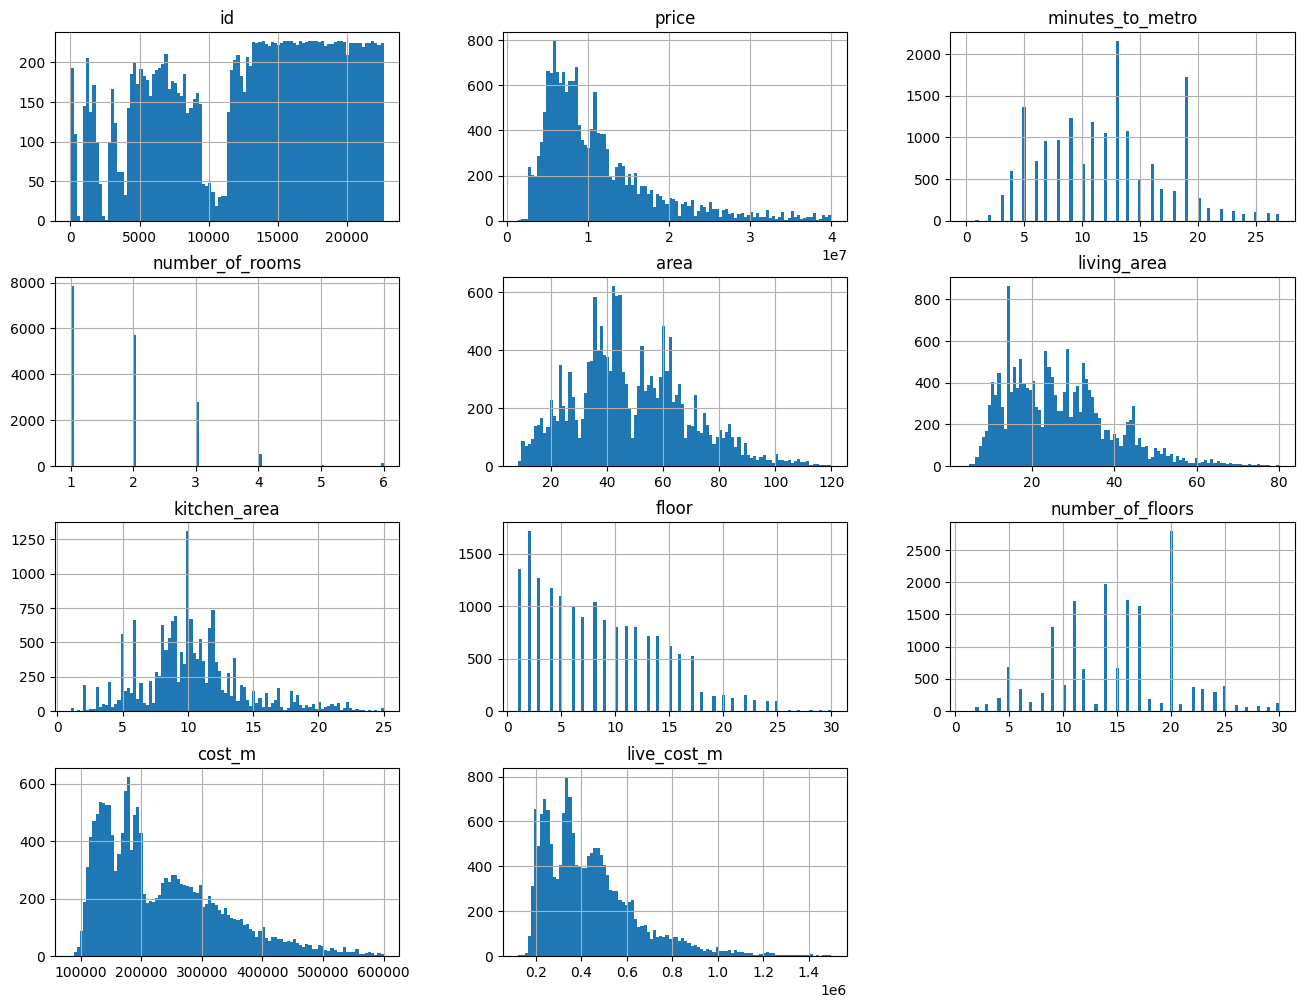

In [34]:
data.hist(bins=100, figsize=(16, 12));

In [29]:
data.describe()

,id,price,minutes_to_metro,number_of_rooms,area,living_area,kitchen_area,floor,number_of_floors,cost_m,live_cost_m
count,22676.000000,2.267600e+04,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000,2.267600e+04,2.267600e+04
mean,11338.500000,3.612132e+07,11.888605,2.207664,71.966827,38.517953,12.594082,9.190466,16.556095,3.466349e+05,7.926582e+05
std,6546.141688,8.282561e+07,6.204457,1.336571,68.368608,38.124278,7.728074,7.549996,9.779297,3.096295e+05,1.838039e+06
min,1.000000,1.150000e+06,0.000000,1.000000,6.000000,2.000000,1.000000,1.000000,1.000000,7.241379e+04,1.220000e+05
25%,5669.750000,7.068116e+06,7.000000,1.000000,37.400000,17.600000,8.600000,4.000000,11.000000,1.704188e+05,3.250000e+05
50%,11338.500000,1.134320e+07,11.000000,2.000000,53.300000,28.500000,10.600000,8.000000,16.000000,2.551964e+05,4.699346e+05
75%,17007.250000,2.479925e+07,15.000000,3.000000,77.140000,43.200000,14.500000,13.000000,20.000000,3.972695e+05,7.500000e+05
max,22676.000000,2.455020e+09,60.000000,12.000000,1117.000000,566.800000,122.000000,92.000000,97.000000,6.450000e+06,7.944471e+07


In [30]:
# Вычисление квартилей и IQR
Q1 = data['minutes_to_metro'].quantile(0.25)
Q3 = data['minutes_to_metro'].quantile(0.75)
IQR = Q3 - Q1

# Границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['minutes_to_metro'] >= lower_bound) & (data['minutes_to_metro'] <= upper_bound)]

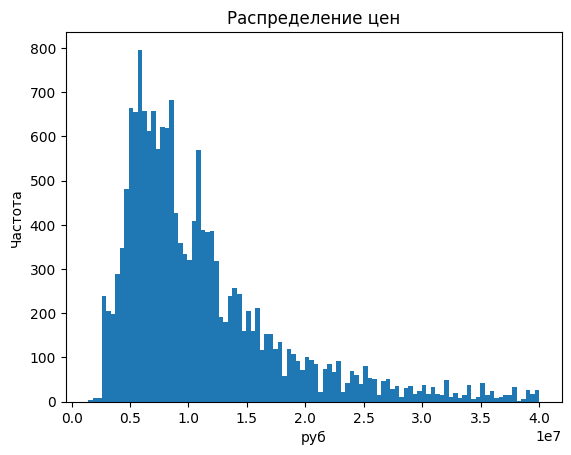

In [33]:
plt.hist(data['price'], bins=100)
plt.title('Распределение цен')
plt.xlabel('руб')
plt.ylabel('Частота')
plt.show()

In [32]:
data = data.loc[data['price'] <= 40000000, :]
data = data.loc[data['minutes_to_metro'] <= 35, :]
data = data.loc[data['number_of_rooms'] <= 6, :]
data = data.loc[data['area'] <= 120, :]
data = data.loc[data['living_area'] <= 80, :]
data = data.loc[data['kitchen_area'] <= 25, :]
data = data.loc[data['floor'] <= 30, :]
data = data.loc[data['number_of_floors'] <= 30, :]
data = data.loc[data['live_cost_m'] <= 1500000, :]
data = data.loc[data['cost_m'] <= 600000, :]

In [35]:
data['price'].describe()

count    1.702600e+04
mean     1.110403e+07
std      6.930631e+06
min      1.420000e+06
25%      6.256455e+06
50%      8.912000e+06
75%      1.367280e+07
max      4.000000e+07
Name: price, dtype: float64

In [36]:
ls_float = [col for col in data.select_dtypes(include='number').columns if col != 'id']
ls_float

['price',
 'minutes_to_metro',
 'number_of_rooms',
 'area',
 'living_area',
 'kitchen_area',
 'floor',
 'number_of_floors',
 'cost_m',
 'live_cost_m']

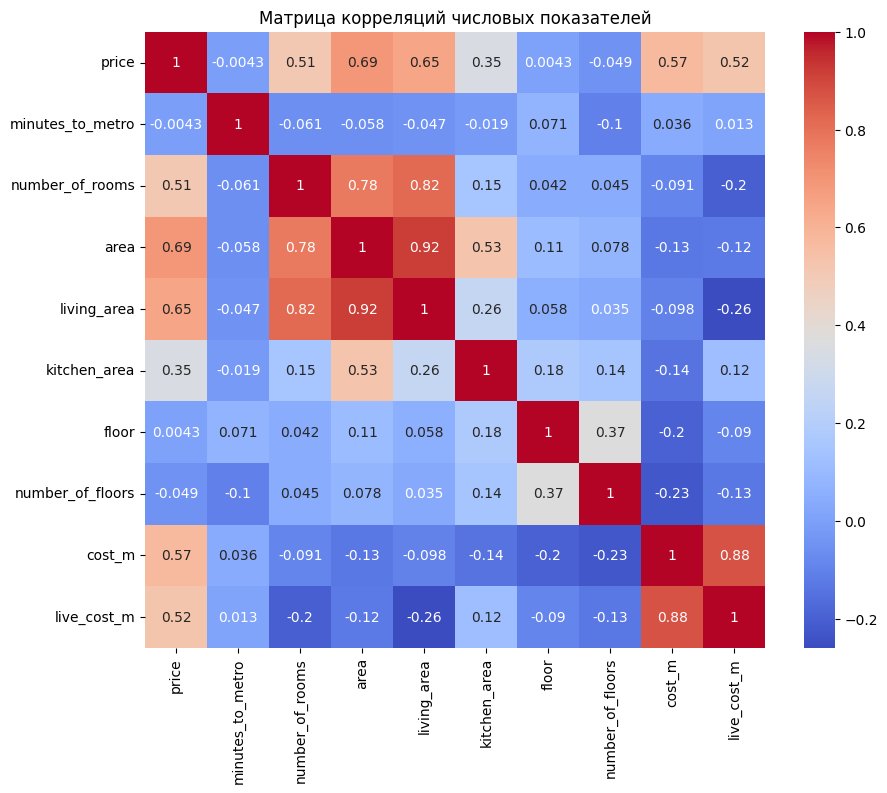

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[ls_float].corr(method='spearman'), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций числовых показателей')
plt.show()

In [376]:
data.head(2)

,id,price,apartment_type,metro_station,minutes_to_metro,region,number_of_rooms,area,living_area,kitchen_area,floor,number_of_floors,renovation,cost_m,live_cost_m
0,1,6300000.0,secondary,опалиха,6.0,moscow,1.0,30.6,11.1,8.5,25.0,25.0,cosmetic,205882.352941,567567.567568
1,2,9000000.0,secondary,павшино,2.0,moscow,1.0,49.2,20.0,10.0,6.0,15.0,european-style renovation,182926.829268,450000.000000


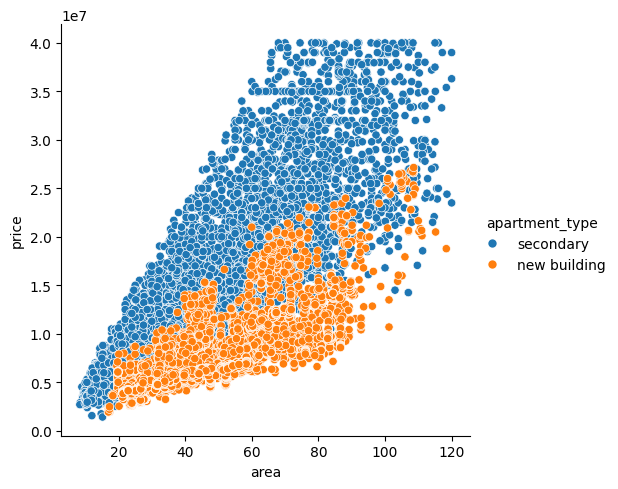

In [42]:
fg = sns.relplot(x='area', 
                 y='price', 
                 data=data,   
             
                 kind='scatter', 
                 hue='apartment_type')

In [43]:
ls_float.remove('price')
ls_float.remove('area')
ls_float.remove('cost_m')
ls_float
#список показателей для прогноза (числовые)

ValueError: list.remove(x): x not in list

In [44]:
columns = list(data.columns)
ls_obj = []

for s in columns:
    if str(data[s].dtype) == 'object':
        ls_obj.append(s)
        
ls_obj.remove('metro_station')
ls_obj.remove('region')
ls_obj
#список показателей для прогноза (категориальные)

['apartment_type', 'renovation']

In [47]:
RANDOM_STATE = 42

columns_to_keep = ls_float + ls_obj
X = data[columns_to_keep]
y = data['price']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, random_state=RANDOM_STATE)

scaler = StandardScaler()
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Масштабируем числовые признаки
X_train_scaled1 = scaler.fit_transform(X_train1[ls_float])
X_test_scaled1 = scaler.transform(X_test1[ls_float])

X_train_scaled1 = pd.DataFrame(X_train_scaled1, columns=ls_float)
X_test_scaled1 = pd.DataFrame(X_test_scaled1, columns=ls_float)

# Преобразуем категориальные признаки с помощью OneHotEncoder
X_train_ohe1 = encoder.fit_transform(X_train1[ls_obj])
X_test_ohe1 = encoder.transform(X_test1[ls_obj])
encoder_col_names1 = encoder.get_feature_names_out(ls_obj)

X_train_ohe1 = pd.DataFrame(X_train_ohe1, columns=encoder_col_names1)
X_test_ohe1 = pd.DataFrame(X_test_ohe1, columns=encoder_col_names1)

# Объединяем числовые и категориальные признаки
X_train_scaled_ohe1 = pd.concat([X_train_scaled1, X_train_ohe1], axis=1)
X_test_scaled_ohe1 = pd.concat([X_test_scaled1, X_test_ohe1], axis=1)

In [49]:
model_lr1 = LinearRegression()

model_lr1.fit(X_train_scaled_ohe1, y_train1)
predictions1 = model_lr1.predict(X_test_scaled_ohe1)

r2_score_linear1 = r2_score(y_test1, predictions1)
r2_score_linear1

0.9033994192609338

In [50]:
def leftovers(y_test, predictions):
    # Создание DataFrame с истинными и предсказанными значениями
    linear_true_predictions = pd.DataFrame(y_test, columns=['price'])
    linear_true_predictions['price_pred'] = predictions
    linear_true_predictions = linear_true_predictions.reset_index()
    linear_true_predictions.columns = ['id', 'price_true', 'price_pred']
    linear_true_predictions['error'] = linear_true_predictions['price_true'] - linear_true_predictions['price_pred']

    # Вывод дополнительных метрик
    mae = linear_true_predictions['error'].abs().mean()
    rmse = (linear_true_predictions['error'] ** 2).mean() ** 0.5
    print(f"Средняя абсолютная ошибка (MAE): {mae:.2f}")
    print(f"Среднеквадратичная ошибка (RMSE): {rmse:.2f}")
    print(f"Min error: {linear_true_predictions['error'].min():.2f}")
    print(f"Max error: {linear_true_predictions['error'].max():.2f}")

    # Увеличение размеров графиков и шрифта
    fig = plt.figure(figsize=(12, 6))
    plt.rcParams.update({'font.size': 12})

    # Гистограмма распределения остатков
    ax1 = fig.add_subplot(121)
    ax1.hist(linear_true_predictions['error'], bins=100, color='skyblue', edgecolor='black')
    ax1.axvline(0, color='r', linestyle='--', label='Нулевая ошибка')
    ax1.axvline(linear_true_predictions['error'].mean(), color='g', linestyle='--', label='Средняя ошибка')
    ax1.text(linear_true_predictions['error'].mean() - 350, 7, "Средняя ошибка", color='g')
    ax1.set_xlim(linear_true_predictions['error'].min(), linear_true_predictions['error'].max())
    ax1.set_title('Распределение остатков')
    ax1.set_xlabel('Price')
    ax1.set_ylabel('Частота')
    ax1.legend()

    # Диаграмма рассеяния остатков
    ax2 = fig.add_subplot(122)
    ax2.scatter(linear_true_predictions['price_pred'], linear_true_predictions['error'], alpha=0.5)
    ax2.axhline(0, color='r', linestyle='--', label='Нулевая ошибка')
    ax2.set_title('Диаграмма рассеяния остатков')
    ax2.set_xlabel('Прогнозируемые значения price')
    ax2.set_ylabel('Разница исходных значений и прогноза')
    ax2.legend()

    plt.show()

Средняя абсолютная ошибка (MAE): 1461146.24
Среднеквадратичная ошибка (RMSE): 2154308.97
Min error: -10915398.81
Max error: 11452036.82


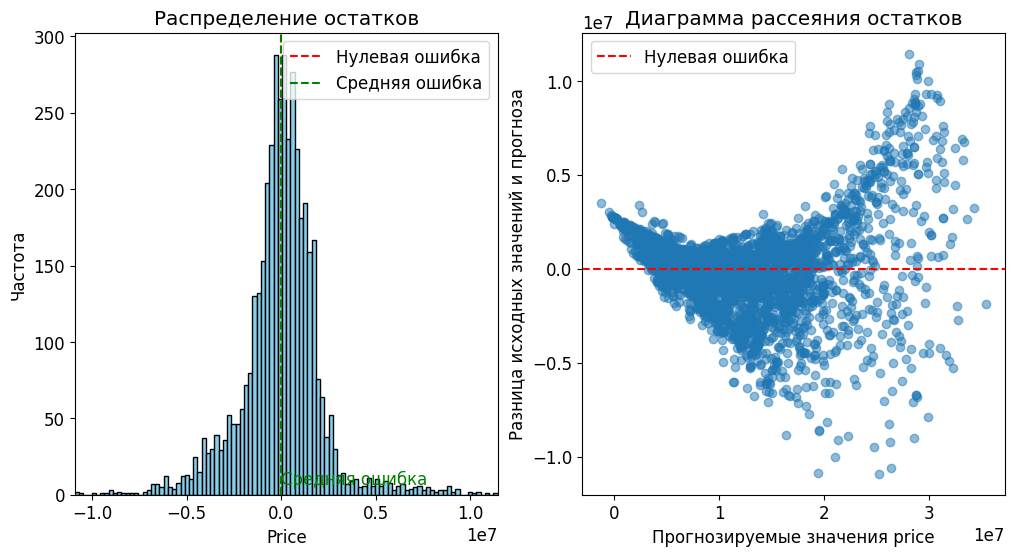

In [51]:
leftovers(y_test1, predictions1)

In [52]:
st.norm.interval(confidence=0.95, loc=np.mean(predictions1),scale=st.sem(predictions1))
#доверительный интервал лучшей модели

(10929344.965192743, 11323894.424888462)